In [1]:
# 0. GOOGLE DRIVE MOUNT
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from zipfile import ZipFile
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import EfficientNetB0, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess



In [ ]:
# Update these paths to match your Iris dataset location
zip_path = '/content/drive/MyDrive/Python /SE4050-DL-Lecture02-main/DL_Assignment/lung_images.zip'
extract_path = './extracted_data' # Extracting to local colab runtime for speed
path = './extracted_data/research_data_set' # Update this based on internal zip structure

# Extract the data
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print('The dataset has been extracted.')

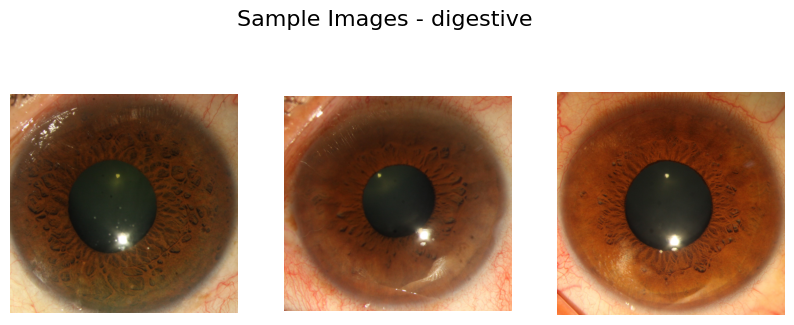

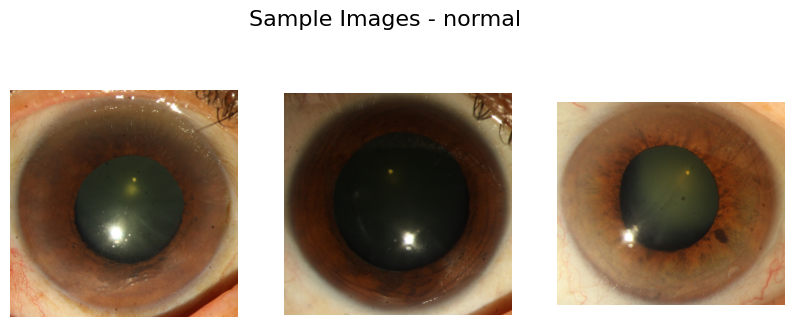

In [6]:
# ==========================================
# 2. DATA EXTRACTION
# ==========================================

path = '/content/drive/MyDrive/Research/New folder'
classes = ['digestive', 'normal']

for cat in classes:
    imgs = os.listdir(os.path.join(path, cat))
    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
    fig.suptitle(f"Sample Images - {cat}", fontsize=16)

    for i in range(3):
        img = Image.open(os.path.join(path, cat, imgs[np.random.randint(len(imgs))]))
        ax[i].imshow(img)
        ax[i].axis("off")
    plt.show()

In [71]:
# ==========================================
# 4. PARAMETERS
# ==========================================
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 20
SPLIT = 0.2

# ==========================================
# 5. LOAD & PREPROCESS DATA
# ==========================================
X, Y = [], []

for i, cat in enumerate(classes):
    images = glob(f'{path}/{cat}/*.JPG')

    for img_path in images:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # IMPORTANT
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        Y.append(i)

X = np.array(X, dtype="float32")
Y = np.array(Y)

Y_cat = keras.utils.to_categorical(Y, num_classes=len(classes))

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_cat,
    test_size=SPLIT,
    random_state=42,
    stratify=Y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Training samples: 124
Validation samples: 32


In [72]:
#==========================================
# 6. DATA AUGMENTATION (MEDICAL-SAFE)
# ==========================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.1),
], name="augmentation")

In [73]:
# ==========================================
# 7. HYBRID MODEL ARCHITECTURE
#    EfficientNetB0 + DenseNet121
# ==========================================
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(input_layer)

# Preprocessing for each branch
eff_input = eff_preprocess(x)
dense_input = dense_preprocess(x)

# Branch A: EfficientNetB0
base_eff = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=eff_input
)
base_eff.trainable = False
eff_feat = layers.GlobalAveragePooling2D()(base_eff.output)

# Branch B: DenseNet121
base_dense = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=dense_input
)
base_dense.trainable = False
dense_feat = layers.GlobalAveragePooling2D()(base_dense.output)

# Feature Fusion
combined = layers.Concatenate()([eff_feat, dense_feat])

# Classification Head
x = layers.Dense(512, activation="relu")(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(len(classes), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output)
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 256, 256,  │          0 │ input_layer_10[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_10      │ (None, 256, 256,  │          0 │ augmentation[0][… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 256, 256,  │          0 │ true_divide_10[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_11      │ (None, 256, 256,  │          0 │ add_5[0][0]       │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_10   │ (None, 262, 262,  │          0 │ true_divide_11[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_11   │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r

 Total params: 12,402,149 (47.31 MB)

 Trainable params: 1,313,538 (5.01 MB)

 Non-trainable params: 11,088,611 (42.30 MB)

In [74]:
# ==========================================
# 8. COMPILE MODEL
# ==========================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [75]:
# ==========================================
# 9. TRAINING
# ==========================================
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1)
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4728 - loss: 1.1148 - val_accuracy: 0.5938 - val_loss: 0.7369 - learning_rate: 1.0000e-04
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 497ms/step - accuracy: 0.6214 - loss: 0.8643 - val_accuracy: 0.6250 - val_loss: 0.6732 - learning_rate: 1.0000e-04
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.6041 - loss: 0.9147 - val_accuracy: 0.6875 - val_loss: 0.6174 - learning_rate: 1.0000e-04
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 0.7742 - loss: 0.5753 - val_accuracy: 0.6875 - val_loss: 0.5678 - learning_rate: 1.0000e-04
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 463ms/step - accuracy: 0.6976 - loss: 0.6132 - val_accuracy: 0.7812 - val_loss: 0.5202 - learning_rate: 1.0000e-04
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.7781 - loss: 0.5089 - val_accuracy: 0.8125 - val_loss: 0.4790 - learning_rate: 1.0000e-04
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.7824 - loss: 0

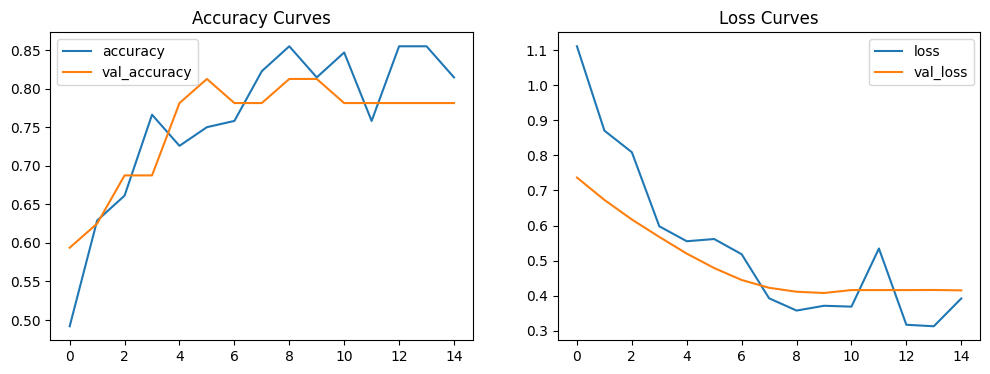

In [76]:
# ==========================================
# 10. TRAINING CURVES
# ==========================================
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history_df[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title('Accuracy Curves')

history_df[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title('Loss Curves')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
              precision    recall  f1-score   support

   digestive       0.73      1.00      0.84        16
      normal       1.00      0.62      0.77        16

    accuracy                           0.81        32
   macro avg       0.86      0.81      0.81        32
weighted avg       0.86      0.81      0.81        32



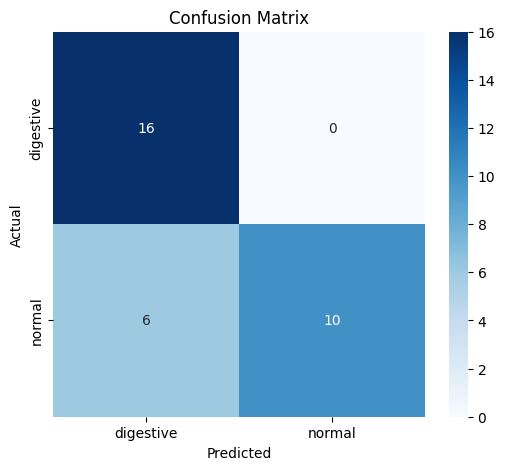

In [77]:
# ==========================================
# 11. EVALUATION
# ==========================================
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

print(classification_report(Y_true, Y_pred_classes, target_names=classes))

cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()